In [1]:
# import libraries
from pathlib import Path
import os

# Main project folder
BASE_DIR = Path(".")

# Dataset paths
dataset1 = BASE_DIR / "Weapon-Detection-1"
dataset2 = BASE_DIR / "kaggle_gun_detection"
dataset3 = BASE_DIR / "SasankYadati-Guns-Dataset-0eb7329"

print("Dataset 1:", dataset1)
print("Dataset 2:", dataset2)
print("Dataset 3:", dataset3)


Dataset 1: Weapon-Detection-1
Dataset 2: kaggle_gun_detection
Dataset 3: SasankYadati-Guns-Dataset-0eb7329


## Count images and labels

In [2]:
def count_files(folder):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
    
    images = []
    labels = []
    
    for file in folder.rglob("*"):
        if file.is_file():
            if file.suffix.lower() in image_extensions:
                images.append(file)
            elif file.suffix.lower() == ".txt":
                labels.append(file)
    
    return images, labels


datasets = {
    "Weapon-Detection-1": dataset1,
    "Kaggle Gun Detection": dataset2,
    "SasankYadati Guns": dataset3
}


for name, path in datasets.items():
    images, labels = count_files(path)
    
    print("=" * 50)
    print(name)
    print("Images :", len(images))
    print("Labels :", len(labels))

Weapon-Detection-1
Images : 40
Labels : 42
Kaggle Gun Detection
Images : 3000
Labels : 3000
SasankYadati Guns
Images : 333
Labels : 333


## Check the folder structure

In [3]:
for name, path in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    
    for item in list(path.iterdir()):
        print(item.name)


Weapon-Detection-1
data.yaml
README.dataset.txt
README.roboflow.txt
test
train
valid

Kaggle Gun Detection
1.jpg
1.txt
10.jpg
10.txt
100.jpg
100.txt
1000.jpg
1000.txt
1001.jpg
1001.txt
1002.jpg
1002.txt
1003.jpg
1003.txt
1004.jpg
1004.txt
1005.jpg
1005.txt
1006.jpg
1006.txt
1007.jpg
1007.txt
1008.jpg
1008.txt
1009.jpg
1009.txt
101.jpg
101.txt
1010.jpg
1010.txt
1011.jpg
1011.txt
1012.jpg
1012.txt
1013.jpg
1013.txt
1014.jpg
1014.txt
1015.jpg
1015.txt
1016.jpg
1016.txt
1017.jpg
1017.txt
1018.jpg
1018.txt
1019.jpg
1019.txt
102.jpg
102.txt
1020.jpg
1020.txt
1021.jpg
1021.txt
1022.jpg
1022.txt
1023.jpg
1023.txt
1024.jpg
1024.txt
1025.jpg
1025.txt
1026.jpg
1026.txt
1027.jpg
1027.txt
1028.jpg
1028.txt
1029.jpg
1029.txt
103.jpg
103.txt
1030.jpg
1030.txt
1031.jpg
1031.txt
1032.jpg
1032.txt
1033.jpg
1033.txt
1034.jpg
1034.txt
1035.jpg
1035.txt
1036.jpg
1036.txt
1037.jpg
1037.txt
1038.jpg
1038.txt
1039.jpg
1039.txt
104.jpg
104.txt
1040.jpg
1040.txt
1041.jpg
1041.txt
1042.jpg
1042.txt
1043.jpg
104

## Inspect the labels

In [4]:
def show_sample_labels(dataset_path, number_of_files=3):
    label_files = list(dataset_path.rglob("*.txt"))
    
    print(f"Found {len(label_files)} label files")
    
    for label_file in label_files[:number_of_files]:
        print("\nFile:", label_file)
        
        with open(label_file, "r", encoding="utf-8") as f:
            content = f.read()
        
        print(content[:1000])


for name, path in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    
    show_sample_labels(path)


Weapon-Detection-1
Found 42 label files

File: Weapon-Detection-1\README.dataset.txt
# Weapon-Detection > 2024-10-03 4:21am
https://universe.roboflow.com/finalyrproject-ui6lv/weapon-detection-lin4o

Provided by a Roboflow user
License: CC BY 4.0



File: Weapon-Detection-1\README.roboflow.txt

Weapon-Detection - v1 2024-10-03 4:21am

This dataset was exported via roboflow.com on September 23, 2025 at 5:20 AM GMT

Roboflow is an end-to-end computer vision platform that helps you
* collaborate with your team on computer vision projects
* collect & organize images
* understand and search unstructured image data
* annotate, and create datasets
* export, train, and deploy computer vision models
* use active learning to improve your dataset over time

For state of the art Computer Vision training notebooks you can use with this dataset,
visit https://github.com/roboflow/notebooks

To find over 100k other datasets and pre-trained models, visit https://universe.roboflow.com

The dataset inclu

## Dataset 1 data.yaml

In [5]:
yaml_file = dataset1 / "data.yaml"

with open(yaml_file, "r", encoding="utf-8") as f:
    print(f.read())

names:
- handgun
- knife
- pistol
- rifle
- shotgun
nc: 5
roboflow:
  license: CC BY 4.0
  project: weapon-detection-lin4o
  url: https://universe.roboflow.com/finalyrproject-ui6lv/weapon-detection-lin4o/dataset/1
  version: 1
  workspace: finalyrproject-ui6lv
test: ../test/images
train: ../train/images
val: ../valid/images



##  Check matching images and labels

In [6]:
def check_matching_files(folder):
    image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
    
    images = {
        file.stem
        for file in folder.rglob("*")
        if file.is_file() and file.suffix.lower() in image_extensions
    }
    
    labels = {
        file.stem
        for file in folder.rglob("*.txt")
    }
    
    missing_labels = images - labels
    extra_labels = labels - images
    
    print("Images:", len(images))
    print("Labels:", len(labels))
    print("Images without labels:", len(missing_labels))
    print("Labels without images:", len(extra_labels))
    
    if missing_labels:
        print("\nExample images without labels:")
        print(list(missing_labels)[:10])
        
    if extra_labels:
        print("\nExample labels without images:")
        print(list(extra_labels)[:10])


for name, path in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    
    check_matching_files(path)


Weapon-Detection-1
Images: 40
Labels: 42
Images without labels: 0
Labels without images: 2

Example labels without images:
['README.dataset', 'README.roboflow']

Kaggle Gun Detection
Images: 3000
Labels: 3000
Images without labels: 0
Labels without images: 0

SasankYadati Guns
Images: 333
Labels: 333
Images without labels: 0
Labels without images: 0


## Check the image dimensions in Dataset 3.

In [7]:
from PIL import Image
from pathlib import Path

dataset3_images = dataset3 / "Images"

image_files = list(dataset3_images.glob("*.jpeg"))

print("Number of images:", len(image_files))

for image_file in image_files[:10]:
    with Image.open(image_file) as img:
        print(image_file.name, "→", img.size)

Number of images: 333
1.jpeg → (347, 145)
10.jpeg → (168, 300)
100.jpeg → (300, 168)
101.jpeg → (300, 168)
102.jpeg → (275, 183)
103.jpeg → (259, 194)
104.jpeg → (299, 168)
105.jpeg → (300, 168)
106.jpeg → (299, 168)
107.jpeg → (300, 168)


## Check Dataset 2's unique class IDs

In [8]:
def get_class_ids(folder):
    class_ids = set()

    for label_file in folder.rglob("*.txt"):
        if label_file.name.startswith("README"):
            continue

        with open(label_file, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()

                if line:
                    class_id = line.split()[0]
                    class_ids.add(class_id)

    return sorted(class_ids)


print("Dataset 1 class IDs:", get_class_ids(dataset1))
print("Dataset 2 class IDs:", get_class_ids(dataset2))
print("Dataset 3 class IDs:", get_class_ids(dataset3))

Dataset 1 class IDs: ['0', '1', '2', '3', '4']
Dataset 2 class IDs: ['1']
Dataset 3 class IDs: ['1', '10', '100', '101', '102', '103', '104', '105', '106', '107', '109', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '122', '123', '124', '125', '126', '127', '128', '129', '131', '133', '134', '136', '137', '138', '139', '140', '141', '142', '143', '144', '147', '148', '149', '15', '150', '151', '153', '154', '155', '156', '157', '158', '159', '16', '161', '162', '164', '165', '166', '167', '168', '169', '17', '170', '171', '172', '173', '175', '177', '178', '179', '18', '180', '181', '182', '185', '186', '187', '188', '189', '192', '193', '194', '197', '199', '2', '20', '204', '205', '206', '207', '21', '211', '213', '215', '217', '22', '221', '222', '225', '229', '23', '231', '232', '234', '237', '238', '239', '24', '242', '25', '250', '26', '265', '27', '28', '29', '3', '30', '31', '310', '32', '33', '34', '35', '36', '37', '38', '4', '41', '

## inspect Dataset 3 properly

In [9]:
from pathlib import Path

dataset3 = Path("SasankYadati-Guns-Dataset-0eb7329")

label_files = list((dataset3 / "Labels").glob("*.txt"))

print("Number of label files:", len(label_files))

for label_file in label_files[:10]:
    print("\nFile:", label_file.name)

    with open(label_file, "r", encoding="utf-8") as f:
        content = f.read().strip()

    print("Content:", content)
    print("Number of values:", len(content.split()))

Number of label files: 333

File: 1.txt
Content: 1
76 45 146 87
Number of values: 5

File: 10.txt
Content: 1
115 130 163 161
Number of values: 5

File: 100.txt
Content: 1
9 23 225 107
Number of values: 5

File: 101.txt
Content: 1
153 25 198 70
Number of values: 5

File: 102.txt
Content: 1
119 87 146 141
Number of values: 5

File: 103.txt
Content: 1
7 69 163 133
Number of values: 5

File: 104.txt
Content: 1
37 64 84 96
Number of values: 5

File: 105.txt
Content: 1
143 16 234 166
Number of values: 5

File: 106.txt
Content: 1
35 32 117 67
Number of values: 5

File: 107.txt
Content: 1
89 45 202 105
Number of values: 5


## image dimensions in Dataset 3.

In [10]:
from PIL import Image
from pathlib import Path

dataset3 = Path("SasankYadati-Guns-Dataset-0eb7329")
image_folder = dataset3 / "Images"

image_files = list(image_folder.glob("*"))

print("Number of images:", len(image_files))

for image_file in image_files[:10]:
    try:
        with Image.open(image_file) as img:
            print(image_file.name, "->", img.size)
    except Exception as e:
        print("Could not read:", image_file.name, e)

Number of images: 333
1.jpeg -> (347, 145)
10.jpeg -> (168, 300)
100.jpeg -> (300, 168)
101.jpeg -> (300, 168)
102.jpeg -> (275, 183)
103.jpeg -> (259, 194)
104.jpeg -> (299, 168)
105.jpeg -> (300, 168)
106.jpeg -> (299, 168)
107.jpeg -> (300, 168)


## Dataset 3 README

In [11]:
readme_path = dataset3 / "README.md"

with open(readme_path, "r", encoding="utf-8") as f:
    readme = f.read()

print(readme)

# Guns-Dataset
The repository contains labelled images of guns taken from various sources.
<br>

## Description
Images folder has images in <code>jpeg</code> format. Labels folder has <code>txt</code> files where in each file, the first line contains the number of objects in the corresponding image and the next lines contain the co-ordinates of the box describing the object.
<br>



# **create the folders**

In [12]:
from pathlib import Path

processed_dataset3 = Path("processed/dataset3_sasank")

images_output = processed_dataset3 / "images"
labels_output = processed_dataset3 / "labels"

images_output.mkdir(parents=True, exist_ok=True)
labels_output.mkdir(parents=True, exist_ok=True)

print("Created:")
print(images_output)
print(labels_output)

Created:
processed\dataset3_sasank\images
processed\dataset3_sasank\labels


## Conversion of the dataset into YOLO format

In [13]:
from PIL import Image
import shutil

dataset3 = Path("SasankYadati-Guns-Dataset-0eb7329")

image_folder = dataset3 / "Images"
label_folder = dataset3 / "Labels"

converted = 0
errors = []

for image_file in image_folder.glob("*"):
    
    # Only process JPEG images
    if image_file.suffix.lower() not in [".jpg", ".jpeg"]:
        continue
    
    label_file = label_folder / f"{image_file.stem}.txt"
    
    if not label_file.exists():
        errors.append(f"Missing label: {image_file.name}")
        continue
    
    try:
        # Get image dimensions
        with Image.open(image_file) as img:
            image_width, image_height = img.size
        
        # Read annotation
        with open(label_file, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if line.strip()]
        
        # First line = number of objects
        number_of_objects = int(lines[0])
        
        yolo_labels = []
        
        # Remaining lines = bounding boxes
        for line in lines[1:]:
            
            values = line.split()
            
            if len(values) != 4:
                errors.append(
                    f"Invalid annotation in {label_file.name}: {line}"
                )
                continue
            
            x1, y1, x2, y2 = map(float, values)
            
            # Convert pixel coordinates to YOLO normalized coordinates
            x_center = ((x1 + x2) / 2) / image_width
            y_center = ((y1 + y2) / 2) / image_height
            
            width = (x2 - x1) / image_width
            height = (y2 - y1) / image_height
            
            # Dataset 3 contains guns only
            class_id = 0
            
            yolo_labels.append(
                f"{class_id} {x_center:.6f} {y_center:.6f} "
                f"{width:.6f} {height:.6f}"
            )
        
        # Check object count
        if number_of_objects != len(yolo_labels):
            errors.append(
                f"Object count mismatch: {label_file.name} "
                f"(declared={number_of_objects}, "
                f"found={len(yolo_labels)})"
            )
        
        # Save converted label
        output_label = labels_output / label_file.name
        
        with open(output_label, "w", encoding="utf-8") as f:
            f.write("\n".join(yolo_labels))
        
        # Copy image
        shutil.copy2(
            image_file,
            images_output / image_file.name
        )
        
        converted += 1
    
    except Exception as e:
        errors.append(f"{image_file.name}: {e}")


print("Conversion completed!")
print("Images converted:", converted)
print("Errors:", len(errors))

if errors:
    print("\nFirst 10 errors:")
    for error in errors[:10]:
        print(error)

Conversion completed!
Images converted: 333
Errors: 0


In [14]:
print("Converted images:", len(list(images_output.iterdir())))
print("Converted labels:", len(list(labels_output.iterdir())))

Converted images: 333
Converted labels: 333


In [15]:
class_mapping_dataset1 = {
    0: 0,   # handgun → gun
    1: 1,   # knife → knife
    2: 0,   # pistol → gun
    3: 0,   # rifle → gun
    4: 0    # shotgun → gun
}

## Make processed copies

In [16]:
from pathlib import Path

processed = Path("processed")

for dataset_name in ["dataset1_weapon", "dataset2_kaggle"]:
    (processed / dataset_name / "images").mkdir(
        parents=True, exist_ok=True
    )
    (processed / dataset_name / "labels").mkdir(
        parents=True, exist_ok=True
    )

print("Processed folders created successfully.")

Processed folders created successfully.


## Standardize Dataset 1

In [17]:
import shutil

dataset1 = Path("Weapon-Detection-1")
output1 = Path("processed/dataset1_weapon")

class_mapping_dataset1 = {
    0: 0,  # handgun → gun
    1: 1,  # knife → knife
    2: 0,  # pistol → gun
    3: 0,  # rifle → gun
    4: 0   # shotgun → gun
}

image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

converted_count = 0
skipped_count = 0

for split in ["train", "valid", "test"]:
    
    image_dir = dataset1 / split / "images"
    label_dir = dataset1 / split / "labels"
    
    if not image_dir.exists():
        continue
    
    for image_file in image_dir.iterdir():
        
        if image_file.suffix.lower() not in image_extensions:
            continue
        
        label_file = label_dir / f"{image_file.stem}.txt"
        
        if not label_file.exists():
            skipped_count += 1
            continue
        
        # Give every file a unique name
        new_name = f"dataset1_{split}_{image_file.name}"
        
        shutil.copy2(
            image_file,
            output1 / "images" / new_name
        )
        
        new_label = output1 / "labels" / f"{Path(new_name).stem}.txt"
        
        with open(label_file, "r", encoding="utf-8") as f:
            lines = [line.strip() for line in f if line.strip()]
        
        new_lines = []
        
        for line in lines:
            values = line.split()
            
            if len(values) != 5:
                continue
            
            old_class = int(values[0])
            
            if old_class not in class_mapping_dataset1:
                continue
            
            new_class = class_mapping_dataset1[old_class]
            
            new_lines.append(
                f"{new_class} {' '.join(values[1:])}"
            )
        
        with open(new_label, "w", encoding="utf-8") as f:
            f.write("\n".join(new_lines))
        
        converted_count += 1

print("Dataset 1 processed.")
print("Images processed:", converted_count)
print("Skipped:", skipped_count)

Dataset 1 processed.
Images processed: 40
Skipped: 0


## Standardize Dataset 2

In [18]:
dataset2 = Path("kaggle_gun_detection")
output2 = Path("processed/dataset2_kaggle")

converted_count = 0
skipped_count = 0

image_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

for image_file in dataset2.iterdir():
    
    if image_file.suffix.lower() not in image_extensions:
        continue
    
    label_file = dataset2 / f"{image_file.stem}.txt"
    
    if not label_file.exists():
        skipped_count += 1
        continue
    
    new_name = f"dataset2_{image_file.name}"
    
    shutil.copy2(
        image_file,
        output2 / "images" / new_name
    )
    
    new_label = output2 / "labels" / f"{Path(new_name).stem}.txt"
    
    with open(label_file, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]
    
    new_lines = []
    
    for line in lines:
        values = line.split()
        
        if len(values) != 5:
            continue
        
        old_class = int(values[0])
        
        # Dataset 2: class 1 = gun
        if old_class == 1:
            new_class = 0
        else:
            continue
        
        new_lines.append(
            f"{new_class} {' '.join(values[1:])}"
        )
    
    with open(new_label, "w", encoding="utf-8") as f:
        f.write("\n".join(new_lines))
    
    converted_count += 1

print("Dataset 2 processed.")
print("Images processed:", converted_count)
print("Skipped:", skipped_count)

Dataset 2 processed.
Images processed: 3000
Skipped: 0


## Verify all three processed datasets

In [19]:
processed_datasets = {
    "Dataset 1": Path("processed/dataset1_weapon"),
    "Dataset 2": Path("processed/dataset2_kaggle"),
    "Dataset 3": Path("processed/dataset3_sasank")
}

for name, path in processed_datasets.items():
    images = list((path / "images").glob("*"))
    labels = list((path / "labels").glob("*.txt"))
    
    print("=" * 50)
    print(name)
    print("Images:", len(images))
    print("Labels:", len(labels))

Dataset 1
Images: 40
Labels: 40
Dataset 2
Images: 3000
Labels: 3000
Dataset 3
Images: 333
Labels: 333


## Check the bounding boxes

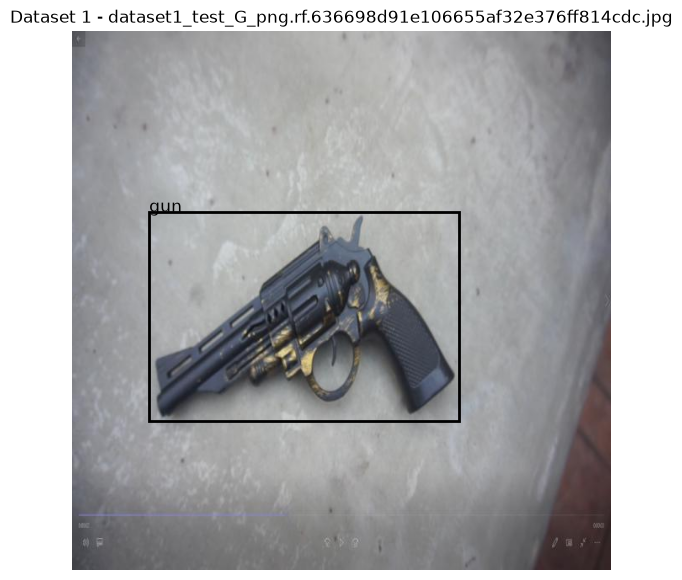

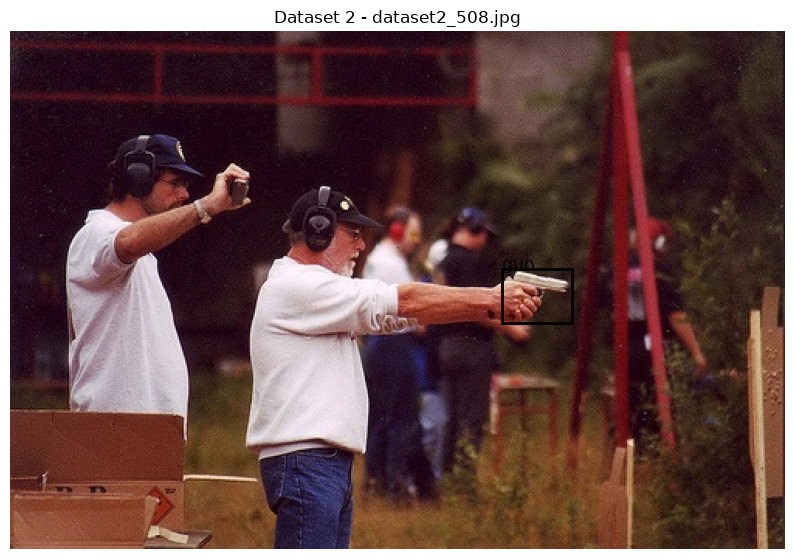

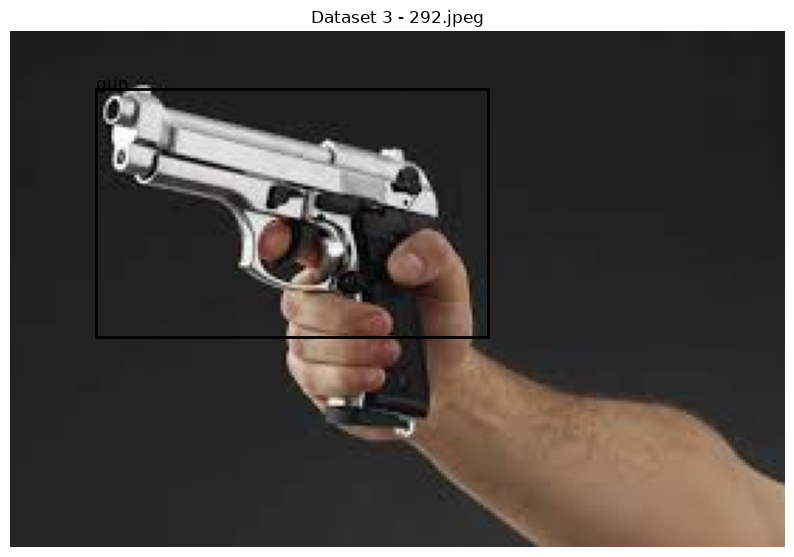

In [20]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

# Processed datasets
processed_datasets = {
    "Dataset 1": Path("processed/dataset1_weapon"),
    "Dataset 2": Path("processed/dataset2_kaggle"),
    "Dataset 3": Path("processed/dataset3_sasank")
}

class_names = {
    0: "gun",
    1: "knife"
}

def show_random_image(dataset_name, dataset_path):
    image_dir = dataset_path / "images"
    label_dir = dataset_path / "labels"

    image_files = list(image_dir.glob("*"))
    image_file = random.choice(image_files)

    label_file = label_dir / f"{image_file.stem}.txt"

    image = Image.open(image_file)
    width, height = image.size

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(image)

    if label_file.exists():
        with open(label_file, "r") as f:
            lines = [line.strip() for line in f if line.strip()]

        for line in lines:
            values = line.split()

            class_id = int(values[0])
            x_center = float(values[1])
            y_center = float(values[2])
            box_width = float(values[3])
            box_height = float(values[4])

            # Convert YOLO coordinates to pixel coordinates
            x_center *= width
            y_center *= height
            box_width *= width
            box_height *= height

            x = x_center - box_width / 2
            y = y_center - box_height / 2

            rectangle = patches.Rectangle(
                (x, y),
                box_width,
                box_height,
                linewidth=2,
                fill=False
            )

            ax.add_patch(rectangle)

            ax.text(
                x,
                y,
                class_names.get(class_id, "unknown"),
                fontsize=12
            )

    ax.set_title(f"{dataset_name} - {image_file.name}")
    ax.axis("off")
    plt.show()


# Show one random image from each dataset
for name, path in processed_datasets.items():
    show_random_image(name, path)

## Detect duplicate images

In [21]:
from pathlib import Path
import hashlib
from collections import defaultdict

processed_datasets = {
    "Dataset 1": Path("processed/dataset1_weapon"),
    "Dataset 2": Path("processed/dataset2_kaggle"),
    "Dataset 3": Path("processed/dataset3_sasank")
}

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Store hash -> list of image paths
hashes = defaultdict(list)

for dataset_name, dataset_path in processed_datasets.items():

    image_dir = dataset_path / "images"

    for image_file in image_dir.iterdir():

        if image_file.suffix.lower() not in image_extensions:
            continue

        # Calculate MD5 hash
        md5 = hashlib.md5()

        with open(image_file, "rb") as f:
            for chunk in iter(lambda: f.read(4096), b""):
                md5.update(chunk)

        file_hash = md5.hexdigest()

        hashes[file_hash].append(image_file)


# Find duplicates
duplicates = {
    file_hash: files
    for file_hash, files in hashes.items()
    if len(files) > 1
}

print("Total images:", sum(len(files) for files in hashes.values()))
print("Unique images:", len(hashes))
print("Duplicate groups:", len(duplicates))

duplicate_count = sum(len(files) - 1 for files in duplicates.values())

print("Duplicate images that can be removed:", duplicate_count)

Total images: 3373
Unique images: 3328
Duplicate groups: 42
Duplicate images that can be removed: 45


## See which images are duplicates

In [22]:
for i, (file_hash, files) in enumerate(duplicates.items(), start=1):

    print(f"\nDuplicate Group {i}")

    for file in files:
        print("   ", file)


Duplicate Group 1
    processed\dataset2_kaggle\images\dataset2_1112.jpg
    processed\dataset2_kaggle\images\dataset2_188.jpg

Duplicate Group 2
    processed\dataset2_kaggle\images\dataset2_1199.jpg
    processed\dataset2_kaggle\images\dataset2_978.jpg

Duplicate Group 3
    processed\dataset2_kaggle\images\dataset2_12.jpg
    processed\dataset2_kaggle\images\dataset2_2851.jpg

Duplicate Group 4
    processed\dataset2_kaggle\images\dataset2_143.jpg
    processed\dataset2_kaggle\images\dataset2_192.jpg

Duplicate Group 5
    processed\dataset2_kaggle\images\dataset2_2406.jpg
    processed\dataset2_kaggle\images\dataset2_2520.jpg

Duplicate Group 6
    processed\dataset2_kaggle\images\dataset2_2456.jpg
    processed\dataset2_kaggle\images\dataset2_2503.jpg
    processed\dataset2_kaggle\images\dataset2_2528.jpg

Duplicate Group 7
    processed\dataset2_kaggle\images\dataset2_2489.jpg
    processed\dataset2_kaggle\images\dataset2_2515.jpg

Duplicate Group 8
    processed\dataset2_kaggle

## Remove duplicate images

In [23]:
from pathlib import Path

removed_images = 0
removed_labels = 0
already_missing = 0

for file_hash, files in duplicates.items():

    # Keep the first existing copy
    existing_files = [f for f in files if f.exists()]

    if not existing_files:
        continue

    keep = existing_files[0]

    print("\nKeeping:", keep)

    # Remove other copies
    for duplicate_image in existing_files[1:]:

        duplicate_label = (
            duplicate_image.parent.parent
            / "labels"
            / f"{duplicate_image.stem}.txt"
        )

        print("Removing:", duplicate_image)

        # Remove image
        if duplicate_image.exists():
            duplicate_image.unlink()
            removed_images += 1
        else:
            already_missing += 1

        # Remove corresponding label
        if duplicate_label.exists():
            duplicate_label.unlink()
            removed_labels += 1

print("\n" + "=" * 50)
print("Duplicate removal completed")
print("=" * 50)

print("Images removed:", removed_images)
print("Labels removed:", removed_labels)
print("Already missing:", already_missing)


Keeping: processed\dataset2_kaggle\images\dataset2_1112.jpg
Removing: processed\dataset2_kaggle\images\dataset2_188.jpg

Keeping: processed\dataset2_kaggle\images\dataset2_1199.jpg
Removing: processed\dataset2_kaggle\images\dataset2_978.jpg

Keeping: processed\dataset2_kaggle\images\dataset2_12.jpg
Removing: processed\dataset2_kaggle\images\dataset2_2851.jpg

Keeping: processed\dataset2_kaggle\images\dataset2_143.jpg
Removing: processed\dataset2_kaggle\images\dataset2_192.jpg

Keeping: processed\dataset2_kaggle\images\dataset2_2406.jpg
Removing: processed\dataset2_kaggle\images\dataset2_2520.jpg

Keeping: processed\dataset2_kaggle\images\dataset2_2456.jpg
Removing: processed\dataset2_kaggle\images\dataset2_2503.jpg
Removing: processed\dataset2_kaggle\images\dataset2_2528.jpg

Keeping: processed\dataset2_kaggle\images\dataset2_2489.jpg
Removing: processed\dataset2_kaggle\images\dataset2_2515.jpg

Keeping: processed\dataset2_kaggle\images\dataset2_2504.jpg
Removing: processed\dataset2_k

In [24]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for name, path in processed_datasets.items():

    images = [
        f for f in (path / "images").iterdir()
        if f.suffix.lower() in image_extensions
    ]

    labels = list((path / "labels").glob("*.txt"))

    print("=" * 50)
    print(name)
    print("Images:", len(images))
    print("Labels:", len(labels))

Dataset 1
Images: 40
Labels: 40
Dataset 2
Images: 2986
Labels: 2986
Dataset 3
Images: 302
Labels: 302


## **Merged dataset**

In [32]:
from pathlib import Path
import shutil

# Source datasets
processed_datasets = {
    "dataset1": Path("processed/dataset1_weapon"),
    "dataset2": Path("processed/dataset2_kaggle"),
    "dataset3": Path("processed/dataset3_sasank")
}

# Final merged dataset
merged_path = Path("weapon_detection_dataset")

# Create folders
(merged_path / "images").mkdir(parents=True, exist_ok=True)
(merged_path / "labels").mkdir(parents=True, exist_ok=True)

# Supported image formats
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

total_images = 0
total_labels = 0

for dataset_name, dataset_path in processed_datasets.items():

    image_dir = dataset_path / "images"
    label_dir = dataset_path / "labels"

    print(f"\nProcessing {dataset_name}...")

    for image_file in image_dir.iterdir():

        if image_file.suffix.lower() not in image_extensions:
            continue

        label_file = label_dir / f"{image_file.stem}.txt"

        # Skip image if annotation is missing
        if not label_file.exists():
            print("Skipping image without label:", image_file.name)
            continue

        # Add dataset name to filename
        # This prevents filename collisions
        new_image_name = f"{dataset_name}_{image_file.name}"
        new_label_name = f"{dataset_name}_{image_file.stem}.txt"

        # Destination paths
        destination_image = merged_path / "images" / new_image_name
        destination_label = merged_path / "labels" / new_label_name

        # Copy image
        shutil.copy2(image_file, destination_image)

        # Copy label
        shutil.copy2(label_file, destination_label)

        total_images += 1
        total_labels += 1

print("\n" + "=" * 50)
print("MERGING COMPLETED")
print("=" * 50)

print("Total images:", total_images)
print("Total labels:", total_labels)


Processing dataset1...

Processing dataset2...

Processing dataset3...

MERGING COMPLETED
Total images: 3328
Total labels: 3328


In [33]:
import random

def copy_split(image_files, split_name):

    for image_file in image_files:

        label_file = source_path / "labels" / f"{image_file.stem}.txt"

        destination_image = (
            final_path / split_name / "images" / image_file.name
        )

        destination_label = (
            final_path / split_name / "labels" / label_file.name
        )

        shutil.copy2(image_file, destination_image)
        shutil.copy2(label_file, destination_label)


source_path = merged_path
final_path = Path("weapon_detection_dataset")

# Create train/valid/test directories
for split in ["train", "valid", "test"]:
    (final_path / split / "images").mkdir(parents=True, exist_ok=True)
    (final_path / split / "labels").mkdir(parents=True, exist_ok=True)

# Get all images
all_images = [
    f for f in (source_path / "images").iterdir()
    if f.suffix.lower() in image_extensions
]

# Shuffle and split (70% train, 15% valid, 15% test)
random.shuffle(all_images)
total = len(all_images)
train_count = int(total * 0.7)
valid_count = int(total * 0.15)

train_images = all_images[:train_count]
valid_images = all_images[train_count:train_count + valid_count]
test_images = all_images[train_count + valid_count:]

copy_split(train_images, "train")
copy_split(valid_images, "valid")
copy_split(test_images, "test")

print("Dataset split completed.")

Dataset split completed.


## Verify the final dataset

In [34]:
for split in ["train", "valid", "test"]:

    image_dir = final_path / split / "images"
    label_dir = final_path / split / "labels"

    images = [
        f for f in image_dir.iterdir()
        if f.suffix.lower() in image_extensions
    ]

    labels = list(label_dir.glob("*.txt"))

    print("=" * 50)
    print(split.upper())
    print("Images:", len(images))
    print("Labels:", len(labels))

TRAIN
Images: 2329
Labels: 2329
VALID
Images: 499
Labels: 499
TEST
Images: 500
Labels: 500


## **Create data.yaml**

In [35]:
yaml_content = """path: weapon_dataset

train: train/images
val: valid/images
test: test/images

nc: 2

names:
  0: gun
  1: knife
"""

with open(final_path / "data.yaml", "w", encoding="utf-8") as f:
    f.write(yaml_content)

print("data.yaml created successfully.")

data.yaml created successfully.


## Final Dataset Summary

This is the final weapon detection dataset after merging the three processed sources and splitting them into train, validation, and test sets.

- Classes: gun, knife
- Total merged images: all images copied into the merged dataset before splitting
- Train set: 70% of the data
- Validation set: 15% of the data
- Test set: 15% of the data
- Final output folder: `weapon_detection_dataset`
- Configuration file: `weapon_detection_dataset/data.yaml`
